# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

I DO HEREBY ACKNOWLEDGE THAT I USED CHATGPT FOR DEBUGGING CODES AND CONVERTING SOME OF THE R CODES INTO PYTHON CODES

In [2]:
# filter dplyr warnings
%load_ext rpy2.ipython
import warnings
warnings.filterwarnings('ignore')

In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"
raw_data = pd.read_csv(url)
print(len(raw_data))

7214


In [4]:
raw_data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


However not all of the rows are useable for the first round of analysis.

There are a number of reasons remove rows because of missing data:
* If the charge date of a defendants Compas scored crime was not within 30 days from when the person was arrested, we assume that because of data quality reasons, that we do not have the right offense.
* We coded the recidivist flag -- `is_recid` -- to be -1 if we could not find a compas case at all.
* In a similar vein, ordinary traffic offenses -- those with a `c_charge_degree` of 'O' -- will not result in Jail time are removed (only two of them).
* We filtered the underlying data from Broward county to include only those rows representing people who had either recidivated in two years, or had at least two years outside of a correctional facility.

In [5]:
import pandas as pd
import numpy as np

# Define variable groups
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Select columns
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score", "is_recid",
    "two_year_recid", "c_jail_in", "c_jail_out"
]].copy()

#  Filtering
df = df[(df["days_b_screening_arrest"] >= -30) & (df["days_b_screening_arrest"] <= 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Type conversions
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", errors="coerce", utc=True)

for col in df.columns:
    if col not in numeric_vars + datetime_vars:
        df[col] = df[col].astype("category")

#  Derived categorical variables with reference levels
df["crime_factor"] = df["c_charge_degree"].astype("category")

df["age_factor"] = pd.Categorical(
    df["age_cat"],
    categories=["25 - 45", "Less than 25", "Greater than 45"],
    ordered=False
)

df["race_factor"] = pd.Categorical(
    df["race"],
    categories=["Caucasian"] + [r for r in df["race"].unique() if r != "Caucasian"]
)

df["gender_factor"] = pd.Categorical(
    df["sex"].map({"Female": "Female", "Male": "Male"}),
    categories=["Male", "Female"]
)

df["score_factor"] = np.where(df["score_text"] != "Low", "HighScore", "LowScore")
df["score_factor"] = df["score_factor"].astype("category")

# Equivalent of nrow(df)
print(len(df))

6172


In [8]:
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [6]:
def glimpse(df, n=10):
    print(f"Rows: {df.shape[0]:,}")
    print(f"Columns: {df.shape[1]}\n")

    for col in df.columns:
        dtype = df[col].dtype
        values = ", ".join(map(str, df[col].head(n).tolist()))
        print(f"$ {col:<25} <{dtype}> {values}")

glimpse(df)

Rows: 6,172
Columns: 18

$ age                       <int64> 69, 34, 24, 44, 41, 43, 39, 27, 23, 37
$ c_charge_degree           <category> F, F, F, M, F, F, M, F, M, M
$ race                      <category> Other, African-American, African-American, Other, Caucasian, Other, Caucasian, Caucasian, African-American, Caucasian
$ age_cat                   <category> Greater than 45, 25 - 45, Less than 25, 25 - 45, 25 - 45, 25 - 45, 25 - 45, 25 - 45, Less than 25, 25 - 45
$ score_text                <category> Low, Low, Low, Low, Medium, Low, Low, Low, Medium, Low
$ sex                       <category> Male, Male, Male, Male, Male, Male, Female, Male, Male, Female
$ priors_count              <int64> 0, 0, 4, 0, 14, 3, 0, 0, 3, 0
$ days_b_screening_arrest   <float64> -1.0, -1.0, -1.0, 0.0, -1.0, -1.0, -1.0, -1.0, 0.0, 0.0
$ decile_score              <int64> 1, 3, 4, 1, 6, 4, 1, 4, 6, 1
$ is_recid                  <category> 0, 1, 1, 0, 1, 0, 0, 0, 1, 0
$ two_year_recid            <category> 0

Higher COMPAS scores are slightly correlated with a longer length of stay.

In [31]:
df["length_of_stay"] = (
    pd.to_datetime(df["c_jail_out"].astype(str).str[:10]) -
    pd.to_datetime(df["c_jail_in"].astype(str).str[:10])
).dt.days

df[["length_of_stay", "decile_score"]].corr().iloc[0, 1]

np.float64(0.20732969161470416)

After filtering we have the following demographic breakdown:

In [7]:
df["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [8]:
df["race"].value_counts()

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [10]:
print("Black defendants: %.2f%%" % (3175 / 6172 * 100))
print("White defendants: %.2f%%" % (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" % (509 / 6172 * 100))
print("Asian defendants: %.2f%%" % (31 / 6172 * 100))
print("Native American defendants: %.2f%%" % (11 / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [11]:
counts = df["score_text"].value_counts()

print("High Low Medium")
print(counts["High"], counts["Low"], counts["Medium"])

High Low Medium
1144 3421 1607


In [12]:
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:
print("Female Male")
counts = df["sex"].value_counts()
print(counts["Female"], counts["Male"])

Female Male
1175 4997


In [14]:
print("Men: %.2f%%" % (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [15]:
len(df[df["two_year_recid"] == 1])

2809

In [16]:
len(df[df["two_year_recid"] == 1]) / len(df) * 100

45.51198963058976

Judges are often presented with two sets of scores from the Compas system -- one that classifies people into High, Medium and Low risk, and a corresponding decile score. There is a clear downward trend in the decile scores as those scores increase for white defendants.

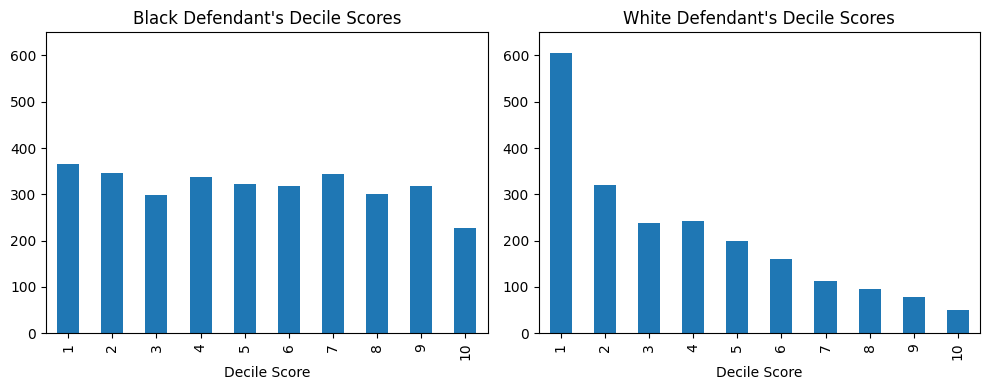

In [17]:
import matplotlib.pyplot as plt

# Filter data
black = df[df["race"] == "African-American"]
white = df[df["race"] == "Caucasian"]

# Create subplots (2 charts side by side)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Black defendants decile scores
black["decile_score"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[0]
)
axes[0].set_xlabel("Decile Score")
axes[0].set_title("Black Defendant's Decile Scores")
axes[0].set_ylim(0, 650)

# White defendants decile scores
white["decile_score"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1]
)
axes[1].set_xlabel("Decile Score")
axes[1].set_title("White Defendant's Decile Scores")
axes[1].set_ylim(0, 650)

plt.tight_layout()
plt.show()

In [18]:
import pandas as pd

pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


## Racial Bias in Compas

After filtering out bad rows, our first question is whether there is a significant difference in Compas scores between races. To do so we need to change some variables into factors, and run a logistic regression, comparing low scores to high scores.

In [23]:
import statsmodels.api as sm
import pandas as pd
import numpy as np

# Re-create score_factor as numeric (0 or 1) directly from score_text
# 'HighScore' corresponds to 1, 'LowScore' corresponds to 0
df["score_factor"] = np.where(df["score_text"] != "Low", 1, 0).astype(int)

# Create dummy variables (equivalent to R factors)
X = pd.get_dummies(
    df[["gender_factor","age_factor","race_factor","priors_count","crime_factor","two_year_recid"]],
    drop_first=True
).astype(int)

# Add intercept
X = sm.add_constant(X)

# Target variable
y = df["score_factor"]

# Logistic regression model
model_glm = sm.Logit(y, X).fit()

# Print summary (equivalent to summary(model_glm) in R)
print(model_glm.summary())

Optimization terminated successfully.
         Current function value: 0.499708
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           score_factor   No. Observations:                 6172
Model:                          Logit   Df Residuals:                     6160
Method:                           MLE   Df Model:                           11
Date:                Sun, 29 Mar 2026   Pseudo R-squ.:                  0.2729
Time:                        03:50:09   Log-Likelihood:                -3084.2
converged:                       True   LL-Null:                       -4241.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -1.5255      0.079    -19.430      0.000

Black defendants are 45% more likely than white defendants to receive a higher score correcting for the seriousness of their crime, previous arrests, and future criminal behavior.

In [35]:
import math

control = math.exp(-1.52554) / (1 + math.exp(-1.52554))

result = math.exp(0.47721) / (1 - control + (control * math.exp(0.47721)))

print(f"{result:.7g}")

1.452841


Women are 19.4% more likely than men to get a higher score.

In [36]:
import math

result = math.exp(0.22127) / (1 - control + (control * math.exp(0.22127)))

print(f"{result:.7g}")

1.194798


Most surprisingly, people under 25 are 2.5 times as likely to get a higher score as middle aged defendants.

In [37]:
import math

result = math.exp(1.30839) / (1 - control + (control * math.exp(1.30839)))

print(f"{result:.7g}")

2.49612


In [27]:
# Predicted probabilities from logistic model
df["pred_prob"] = model_glm.predict(X)

# Predicted class (threshold = 0.5)
df["pred_class"] = df["pred_prob"].apply(lambda x: "Recid" if x >= 0.5 else "No Recid")


In [28]:
import pandas as pd

print("\n— Overall Confusion Matrix —")

overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)

print(overall_cm)

TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]

n = overall_cm.values.sum()

accuracy  = (TP + TN) / n
precision = TP / (TP + FP)
recall    = TP / (TP + FN)
fpr       = FP / (FP + TN)
fnr       = FN / (FN + TP)

print(f"\nAccuracy  : {accuracy:.3f}")
print(f"Precision : {precision:.3f}")
print(f"Recall    : {recall:.3f}")
print(f"FPR       : {fpr:.3f}")
print(f"FNR       : {fnr:.3f}")


— Overall Confusion Matrix —
Actual        0     1
Predicted            
No Recid   2653   945
Recid       710  1864

Accuracy  : 0.732
Precision : 0.724
Recall    : 0.664
FPR       : 0.211
FNR       : 0.336


In [29]:
import pandas as pd

print("\n— Confusion Matrix by Race —")

# Create actual and predicted variables
df["actual"] = df["two_year_recid"].astype(int)
df["pred"] = (df["pred_class"] == "Recid").astype(int)

def compute_metrics(group):
    TP = ((group["pred"] == 1) & (group["actual"] == 1)).sum()
    TN = ((group["pred"] == 0) & (group["actual"] == 0)).sum()
    FP = ((group["pred"] == 1) & (group["actual"] == 0)).sum()
    FN = ((group["pred"] == 0) & (group["actual"] == 1)).sum()

    n = len(group)

    accuracy  = round((TP + TN) / n, 3)
    precision = round(TP / (TP + FP) if (TP + FP) > 0 else 0, 3)
    recall    = round(TP / (TP + FN) if (TP + FN) > 0 else 0, 3)
    fpr       = round(FP / (FP + TN) if (FP + TN) > 0 else 0, 3)
    fnr       = round(FN / (FN + TP) if (FN + TP) > 0 else 0, 3)

    return pd.Series({
        "n": n,
        "TP": TP,
        "TN": TN,
        "FP": FP,
        "FN": FN,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "FPR": fpr,
        "FNR": fnr
    })

race_metrics = (
    df.groupby("race")
      .apply(compute_metrics)
      .sort_values("n", ascending=False)
)

print(race_metrics)


— Confusion Matrix by Race —
                       n      TP      TN     FP     FN  Accuracy  Precision  \
race                                                                          
African-American  3175.0  1373.0   959.0  555.0  288.0     0.734      0.712   
Caucasian         2103.0   381.0  1148.0  133.0  441.0     0.727      0.741   
Hispanic           509.0    81.0   306.0   14.0  108.0     0.760      0.853   
Other              343.0    22.0   216.0    3.0  102.0     0.694      0.880   
Asian               31.0     2.0    22.0    1.0    6.0     0.774      0.667   
Native American     11.0     5.0     2.0    4.0    0.0     0.636      0.556   

                  Recall    FPR    FNR  
race                                    
African-American   0.827  0.367  0.173  
Caucasian          0.464  0.104  0.536  
Hispanic           0.429  0.044  0.571  
Other              0.177  0.014  0.823  
Asian              0.250  0.043  0.750  
Native American    1.000  0.667  0.000  


In [30]:
print("\n— FPR and FNR Disparity by Race —")

# Select required columns
disparity = race_metrics[["n", "FPR", "FNR"]].copy()
disparity["race"] = disparity.index

# Get Caucasian reference values
caucasian_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
caucasian_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

# Compute disparities
disparity["delta_FPR"] = (disparity["FPR"] - caucasian_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - caucasian_fnr).round(3)

# Reorder columns to match R output
disparity = disparity[["race", "n", "FPR", "FNR", "delta_FPR", "delta_FNR"]]

print(disparity)


— FPR and FNR Disparity by Race —
                              race       n    FPR    FNR  delta_FPR  delta_FNR
race                                                                          
African-American  African-American  3175.0  0.367  0.173      0.263     -0.363
Caucasian                Caucasian  2103.0  0.104  0.536      0.000      0.000
Hispanic                  Hispanic   509.0  0.044  0.571     -0.060      0.035
Other                        Other   343.0  0.014  0.823     -0.090      0.287
Asian                        Asian    31.0  0.043  0.750     -0.061      0.214
Native American    Native American    11.0  0.667  0.000      0.563     -0.536
